# Power Spectrum, Growth & Halo Mass Function — a BEoRN tutorial

This notebook walks through the analytic cosmology layer of BEoRN, one physics concept per section. Every section follows the same pattern:

* **Physics** — the concept and BEoRN's default (numpy) implementation,
* **Validation** — comparison against an external package where one is available (CAMB, colossus),
* **GPU** — execution on an accelerator through the `backend='jax'|'torch'` option,
* **Autodiff** — gradients with respect to the physical parameters, cross-checked against finite differences.

All GPU/autodiff features are **opt-in**: the numpy defaults are untouched, and each demo cell degrades gracefully — if JAX/torch is not installed or no GPU is present, it prints a message and moves on. Optional dependencies: `camb`, `colossus`, `jax`, `torch`.

**Contents**
1. [Setup and environment detection](#sec1)
2. [Linear matter power spectrum P(k)](#sec2): [validation](#sec2-1) · [GPU](#sec2-2) · [autodiff I](#sec2-3) · [autodiff II](#sec2-4)
3. [Growth factor D(z) and growth rate f₁](#sec3): [validation](#sec3-1) · [GPU](#sec3-2) · [autodiff](#sec3-3)
4. [Halo mass function](#sec4): [validation](#sec4-1) · [GPU & speed](#sec4-2) · [autodiff I](#sec4-3) · [autodiff II](#sec4-4)
5. [Summary](#sec5)

<a id="sec1"></a>
## 1. Setup and environment detection

Imports, the fiducial cosmology, and a single detection cell that every later section relies on: `_JAX` / `_TORCH_AVAILABLE` flags, the `torch_gpu` device (CUDA or Apple-Silicon MPS), and a small `bench()` timing helper.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.integrate import quad

from beorn.structs import Parameters
from beorn.lpt import EisensteinHu, DiscoEB, get_power_spectrum
from beorn.cosmo import D
from beorn.mass_function import (
    HaloMassFunction, PressSchechter, ShethTormen,
)

param = Parameters()
cosmo = param.cosmology
M     = np.logspace(8, 15, 100)
dlnM  = np.diff(np.log(M)).mean()   # uniform log-spacing ~= ln(10)*7/99
z     = 7.0
print(f'Ωm={cosmo.Om}  Ωb={cosmo.Ob}  h={cosmo.h0}  σ₈={cosmo.sigma_8}  ns={cosmo.ns}')

Ωm=0.315  Ωb=0.045  h=0.673  σ₈=0.83  ns=0.96


In [2]:
import time

# ── Optional-dependency and device detection (used by every later section) ───
try:
    import jax
    import jax.numpy as jnp
    jax.config.update('jax_enable_x64', True)   # float64 (jax default is float32)
    _JAX = True
    print(f'JAX {jax.__version__} — devices: {jax.devices()}')
except ImportError:
    _JAX = False
    print('JAX is not installed — jax autodiff/GPU demos will be skipped.')

try:
    import torch
    _TORCH_AVAILABLE = True
    torch_gpu = ('cuda' if torch.cuda.is_available()
                 else 'mps' if torch.backends.mps.is_available() else None)
    print(f'torch {torch.__version__} — CUDA={torch.cuda.is_available()}  '
          f'MPS={torch.backends.mps.is_available()}  → GPU device: {torch_gpu}')
except ImportError:
    _TORCH_AVAILABLE = False
    torch_gpu = None
    print('torch is not installed — torch autodiff/GPU demos will be skipped.')

if torch_gpu is None:
    print('GPUs not available — GPU cells will report this and continue on CPU.')
if torch_gpu == 'mps':
    print('Note: MPS (Apple GPU) supports float32 only; GPU cells use float32 there.')

def bench(fn, n=5):
    """Best-of-n wall time in seconds; one warm-up call (jit compile, caches)."""
    fn()
    ts = []
    for _ in range(n):
        t0 = time.perf_counter(); fn(); ts.append(time.perf_counter() - t0)
    return min(ts)

JAX 0.10.2 — devices: [CudaDevice(id=0)]
torch 2.13.0+cu130 — CUDA=True  MPS=False  → GPU device: cuda


<a id="sec2"></a>
## 2. Linear matter power spectrum P(k)

**Physics.** The linear power spectrum is $P(k, z) = A_s\, k^{n_s}\, T^2(k)\, D^2(z)$, where $T(k)$ is the transfer function and $A_s$ is normalised so that the rms fluctuation in 8 Mpc/h spheres equals $\sigma_8$. BEoRN's default is the Eisenstein & Hu (1998) fitting function — the smooth *no-wiggle* form, with the full BAO *wiggle* form optional.

sigma_8 target  = 0.83
A_s (no-wiggle) = 2.85359e+06
A_s (wiggle)    = 3.04762e+06


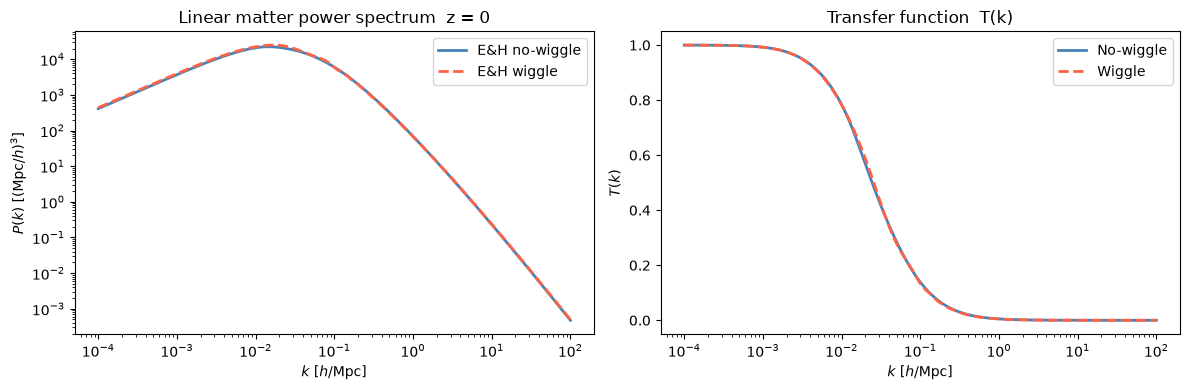

In [3]:
k = np.logspace(-4, 2, 500)

ps_nw  = EisensteinHu(param, wiggle=False)   # smooth no-wiggle (default)
ps_wig = EisensteinHu(param, wiggle=True)    # full BAO wiggles

print(f"sigma_8 target  = {param.cosmology.sigma_8}")
print(f"A_s (no-wiggle) = {ps_nw.A_s:.5e}")
print(f"A_s (wiggle)    = {ps_wig.A_s:.5e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.loglog(k, ps_nw.P(k, z=0),  lw=2.0, color='steelblue', label='E&H no-wiggle')
ax.loglog(k, ps_wig.P(k, z=0), lw=2.0, color='tomato', ls='--', label='E&H wiggle')
ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$')
ax.set_ylabel(r'$P(k)\ [(\mathrm{Mpc}/h)^3]$')
ax.set_title('Linear matter power spectrum  z = 0')
ax.legend()

ax = axes[1]
ax.semilogx(k, ps_nw.transfer(k),  lw=2.0, color='steelblue', label='No-wiggle')
ax.semilogx(k, ps_wig.transfer(k), lw=2.0, color='tomato', ls='--', label='Wiggle')
ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$')
ax.set_ylabel(r'$T(k)$')
ax.set_title('Transfer function  T(k)')
ax.legend()

plt.tight_layout()
plt.show()

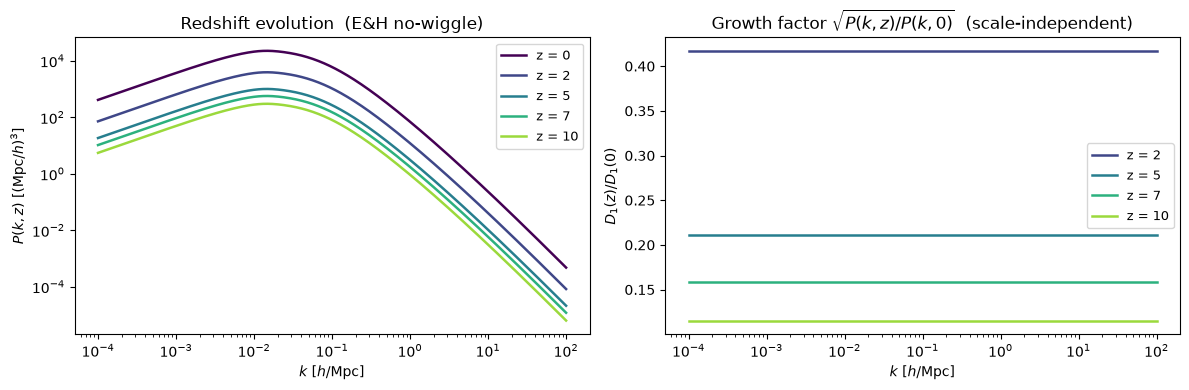

In [4]:
redshifts = [0.0, 2.0, 5.0, 7.0, 10.0]
colors    = plt.cm.viridis(np.linspace(0.0, 0.85, len(redshifts)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for z_i, c in zip(redshifts, colors):
    ax.loglog(k, ps_nw.P(k, z=z_i), lw=1.8, color=c, label=f'z = {z_i:.0f}')
ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$')
ax.set_ylabel(r'$P(k, z)\ [(\mathrm{Mpc}/h)^3]$')
ax.set_title('Redshift evolution  (E&H no-wiggle)')
ax.legend(fontsize=9)

P0 = ps_nw.P(k, z=0.0)
ax = axes[1]
for z_i, c in zip(redshifts[1:], colors[1:]):
    growth = np.sqrt(ps_nw.P(k, z=z_i) / P0)
    ax.semilogx(k, growth, lw=1.8, color=c, label=f'z = {z_i:.0f}')
ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$')
ax.set_ylabel(r'$D_1(z) / D_1(0)$')
ax.set_title(r'Growth factor $\sqrt{P(k,z)/P(k,0)}$  (scale-independent)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

<a id="sec2-1"></a>
### 2.1. Validation

Internal consistency first: integrating the spectrum in a top-hat window of 8 Mpc/h must return the input $\sigma_8$. Then, if `camb` is installed, we compare the E&H shapes and the growth ratio against a Boltzmann code (expect few-% agreement of the fitting function, sub-% for the growth).

In [5]:
def sigma_r(ps, R, z=0):
    """rms density fluctuation in spheres of radius R (Mpc/h)."""
    def integrand(lnk):
        k_ = np.exp(lnk)
        x  = k_ * R
        W  = 3 * (np.sin(x) - x * np.cos(x)) / x**3
        return k_**3 * ps.P(k_, z=z) * W**2 / (2 * np.pi**2)
    result, _ = quad(integrand, np.log(1e-4), np.log(1e3), limit=300)
    return np.sqrt(result)

k = np.logspace(-4, 2, 500)
ps_nw  = EisensteinHu(param, wiggle=False)
ps_wig = EisensteinHu(param, wiggle=True)

for label, ps in [('no-wiggle', ps_nw), ('wiggle', ps_wig)]:
    s8 = sigma_r(ps, R=8, z=0)
    print(f'σ₈ ({label}) = {s8:.5f}   target = {cosmo.sigma_8}')


σ₈ (no-wiggle) = 0.83000   target = 0.83
σ₈ (wiggle) = 0.83001   target = 0.83


In [6]:
try:
    import camb
    _CAMB = True
except ImportError:
    _CAMB = False

if _CAMB:

    h0, Om, Ob, ns_cosm, sig8 = cosmo.h0, cosmo.Om, cosmo.Ob, cosmo.ns, cosmo.sigma_8

    pars = camb.CAMBparams()
    pars.set_cosmology(H0=100*h0, ombh2=Ob*h0**2, omch2=(Om-Ob)*h0**2, TCMB=2.7255)
    pars.InitPower.set_params(ns=ns_cosm, As=2.1e-9)
    pars.set_matter_power(redshifts=[0.0, 7.0], kmax=200.0)
    results = camb.get_results(pars)

    sig8_camb  = results.get_sigma8_0()
    rescale_sq = (sig8 / sig8_camb) ** 2

    kh_c, z_c, Pk_c = results.get_matter_power_spectrum(minkh=1e-4, maxkh=100.0, npoints=500)
    Pk_camb_z0 = Pk_c[0] * rescale_sq
    Pk_camb_z7 = Pk_c[1] * rescale_sq

    # # ── DISCO-EB (optional) ───────────────────────────────────────────────────────
    # _DISCOEB_AVAILABLE = False
    # try:
    #     print('Initialising DiscoEB (JIT compilation may take ~1 min on first run)...')
    #     ps_deb = DiscoEB(param, num_k=256)  # kmax_hmpc=1.0 h/Mpc by default
    #     _DISCOEB_AVAILABLE = True
    #     print('DiscoEB ready.')
    # except ImportError:
    #     print('disco-eb not installed — skipping DISCO-EB comparison.')
    #     print('Install: pip install git+https://github.com/ohahn/DISCO-EB.git')

    # ── P(k) comparison plots ─────────────────────────────────────────────────────
    k_plt = np.logspace(-3, 1.5, 400)
    fig, ax = plt.subplots(figsize=(8, 4))

    for z_plt, Pk_cam, lw in zip([0.0, 7.0], [Pk_camb_z0, Pk_camb_z7], [2.5,4.0]):
        ax.loglog(k_plt, ps_nw.P(k_plt, z=z_plt),  lw=lw, ls='-',   c='C0', label='E&H no-wiggle' if z_plt == 0.0 else None)
        ax.loglog(k_plt, ps_wig.P(k_plt, z=z_plt), lw=lw, ls='--',  c='C1', label='E&H wiggle'  if z_plt == 0.0 else None)
        ax.loglog(kh_c,  Pk_cam,                   lw=lw, ls=':',   c='C2',  label='CAMB' if z_plt == 0.0 else None)
        # if _DISCOEB_AVAILABLE:
        #     k_deb = k_plt[k_plt <= ps_deb._kmax_hmpc]
        #     ax.loglog(k_deb, ps_deb.P(k_deb, z=z_plt), lw=1.5, ls='-.', label='DISCO-EB')
        ax.plot([], [], lw=lw, ls='-', color='k', label=f'z={z_plt:.0f}')
    ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
    ax.set_ylabel(r'$P(k)\;[(\mathrm{Mpc}/h)^3]$')
    # ax.set_title(f'$z = {z_plt}$')
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_ylim(1e-2, 5e4)
    ax.set_xlim(4e-4, 40)

    plt.tight_layout()
    plt.show()

    # ── Ratio to CAMB ─────────────────────────────────────────────────────────────
    from scipy.interpolate import interp1d as _interp1d
    log_cam = _interp1d(np.log(kh_c), np.log(Pk_camb_z0), kind='linear',
                        bounds_error=False, fill_value='extrapolate')
    Pk_cam_ref = np.exp(log_cam(np.log(k_plt)))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.semilogx(k_plt, ps_nw.P(k_plt,  z=0) / Pk_cam_ref, label='E&H no-wiggle / CAMB')
    ax.semilogx(k_plt, ps_wig.P(k_plt, z=0) / Pk_cam_ref, label='E&H wiggle / CAMB', ls='--')
    # if _DISCOEB_AVAILABLE:
    #     k_deb = k_plt[k_plt <= ps_deb._kmax_hmpc]
    #     Pk_cam_deb = np.exp(log_cam(np.log(k_deb)))
    #     ax.semilogx(k_deb, ps_deb.P(k_deb, z=0) / Pk_cam_deb, label='DISCO-EB / CAMB', ls='-.')
    ax.axhline(1, color='k', lw=0.8, ls=':')
    ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
    ax.set_ylabel(r'$P(k)\,/\,P_\mathrm{CAMB}(k)$')
    ax.set_title('Ratio to CAMB at $z=0$')
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_ylim(0.8, 1.3)
    ax.set_xlim(4e-4, 40)
    plt.tight_layout()
    plt.show()

    # ── Growth factor comparison ──────────────────────────────────────────────────
    idx7 = np.argmin(np.abs(kh_c - 0.1))
    D_ratio_beorn = ps_nw._growth_ratio(7.0)
    D_ratio_camb  = np.sqrt(Pk_c[1][idx7] / Pk_c[0][idx7])
    print(f'D(z=7)/D(0): BEoRN={D_ratio_beorn:.4f}  CAMB={D_ratio_camb:.4f}  '
          f'diff={abs(D_ratio_beorn-D_ratio_camb)/D_ratio_camb*100:.2f}%')
else:
    print('camb is not installed — skipping CAMB validation.')

camb is not installed — skipping CAMB validation.


<a id="sec2-2"></a>
### 2.2. GPU execution

`EisensteinHu(param, backend='jax'|'torch')` dispatches to backend-generic pure functions (`beorn.lpt.pk_eh_nowiggle`) — same formulas, device-resident arrays. Below: accuracy against the numpy class and kernel speed on a large k-grid. Expected accuracy: ~10⁻⁴ (documented growth-quadrature difference), plus float32 noise on MPS.

In [7]:
from beorn.lpt import pk_eh_nowiggle, transfer_eh_nowiggle

theta0 = dict(Om=cosmo.Om, Ob=cosmo.Ob, h0=cosmo.h0, ns=cosmo.ns, sigma_8=cosmo.sigma_8)
k_grad, z_grad = np.logspace(-3, 1.5, 200), 7.0
P_ref = ps_nw.P(k_grad, z=z_grad)                      # numpy class reference

# accuracy: pure function, every available backend
for be in ['numpy'] + (['jax'] if _JAX else []) + (['torch'] if _TORCH_AVAILABLE else []):
    P_be = pk_eh_nowiggle(k_grad, z_grad, backend=be, **theta0)
    P_be = P_be.numpy() if be == 'torch' else np.asarray(P_be)
    print(f'pk_eh_nowiggle {be:6s} vs numpy class: max|ratio-1| = '
          f'{np.max(np.abs(P_be / P_ref - 1)):.2e}')

# GPU: accuracy + transfer-function kernel speed on a large k grid
if _TORCH_AVAILABLE and torch_gpu is not None:
    dtype_gpu = torch.float32 if torch_gpu == 'mps' else torch.float64
    kt   = torch.as_tensor(k_grad, dtype=dtype_gpu, device=torch_gpu)
    args = [torch.tensor(v, dtype=dtype_gpu, device=torch_gpu) for v in theta0.values()]
    P_gpu = pk_eh_nowiggle(kt, z_grad, *args, backend='torch').cpu().double().numpy()
    print(f'\npk_eh_nowiggle on torch {torch_gpu} ({str(dtype_gpu).split(".")[-1]}): '
          f'max|ratio-1| vs numpy class = {np.max(np.abs(P_gpu / P_ref - 1)):.2e}')

    k_big = np.logspace(-4, 2, 2**22)
    t_cpu = bench(lambda: transfer_eh_nowiggle(k_big, **{n: theta0[n] for n in ['Om','Ob','h0']}))
    kb_g  = torch.as_tensor(k_big, dtype=dtype_gpu, device=torch_gpu)
    sync  = torch.mps.synchronize if torch_gpu == 'mps' else torch.cuda.synchronize
    ag    = [torch.tensor(theta0[n], dtype=dtype_gpu, device=torch_gpu) for n in ['Om','Ob','h0']]
    def _run_gpu():
        transfer_eh_nowiggle(kb_g, *ag, backend='torch'); sync()
    t_gpu = bench(_run_gpu)
    print(f'T(k) kernel, {k_big.size:.1e} values:  numpy cpu {t_cpu*1e3:7.1f} ms   '
          f'torch {torch_gpu} {t_gpu*1e3:7.1f} ms   '
          f'speedup: {t_cpu/t_gpu:.1f}× faster on GPU')
else:
    print('\nGPUs not available — GPU execution test skipped.')

pk_eh_nowiggle numpy  vs numpy class: max|ratio-1| = 7.29e-05
pk_eh_nowiggle jax    vs numpy class: max|ratio-1| = 7.29e-05
pk_eh_nowiggle torch  vs numpy class: max|ratio-1| = 7.29e-05

pk_eh_nowiggle on torch cuda (float64): max|ratio-1| vs numpy class = 7.29e-05
T(k) kernel, 4.2e+06 values:  numpy cpu    94.0 ms   torch cuda     0.7 ms   speedup: 128.2× faster on GPU


<a id="sec2-3"></a>
### 2.3. Autodiff I — analytic sanity check ($A_s$, $n_s$)

Amplitude and tilt enter the spectrum analytically ($\partial\ln P/\partial\ln A_s = 1$, $\partial\ln P/\partial n_s = \ln k$), which makes them a clean first test of the autodiff machinery: here $T^2(k)$ is deliberately frozen as a constant so the JAX gradients can be compared against exact expressions.

In [8]:
if _JAX:
    import jax
    import jax.numpy as jnp
    jax.config.update('jax_enable_x64', True)

    # T²(k) and D(z)² are frozen numpy constants; differentiate only
    # through A_s and n_s which enter the spectrum analytically.
    T_sq_np  = ps_nw.transfer(k) ** 2
    D_sq_0   = float(ps_nw._growth_ratio(0.0) ** 2)
    k_jax    = jnp.asarray(k)
    T_sq_jax = jnp.asarray(T_sq_np)
    A_s_ref  = float(ps_nw.A_s)
    ns_ref   = float(param.cosmology.ns)

    def Pk_jax(A_s, ns_scalar):
        """P(k, z=0): differentiable w.r.t. A_s and n_s (T² is a constant)."""
        return A_s * k_jax ** ns_scalar * T_sq_jax * D_sq_0

    # ∂(Σ P)/∂A_s  should equal  Σ P / A_s
    grad_As  = jax.grad(lambda As: Pk_jax(As, ns_ref).sum())(A_s_ref)
    check_As = float(np.sum(ps_nw.P(k, z=0)) / A_s_ref)
    print(f'∂(ΣP)/∂A_s   JAX = {float(grad_As):.6e}   analytic = {check_As:.6e}   '
          f'rel err = {abs(float(grad_As) - check_As) / check_As:.2e}')

    # ∂P_i/∂n_s  should equal  P_i · ln k_i
    dPk_dns  = jax.jacobian(lambda ns: Pk_jax(A_s_ref, ns))(ns_ref)
    check_ns = ps_nw.P(k, z=0) * np.log(k)
    valid_k  = np.abs(np.log(k)) > 0.1   # exclude k ≈ 1 where analytic → 0
    max_err  = float(np.max(np.abs(np.asarray(dPk_dns)[valid_k] - check_ns[valid_k])
                            / np.abs(check_ns[valid_k])))
    print(f'∂P_i/∂n_s   max rel err vs P·ln k = {max_err:.2e}')
else:
    print('JAX is not installed — skipping this autodiff demo.')

∂(ΣP)/∂A_s   JAX = 8.941094e-01   analytic = 8.941094e-01   rel err = 1.24e-16
∂P_i/∂n_s   max rel err vs P·ln k = 4.12e-16


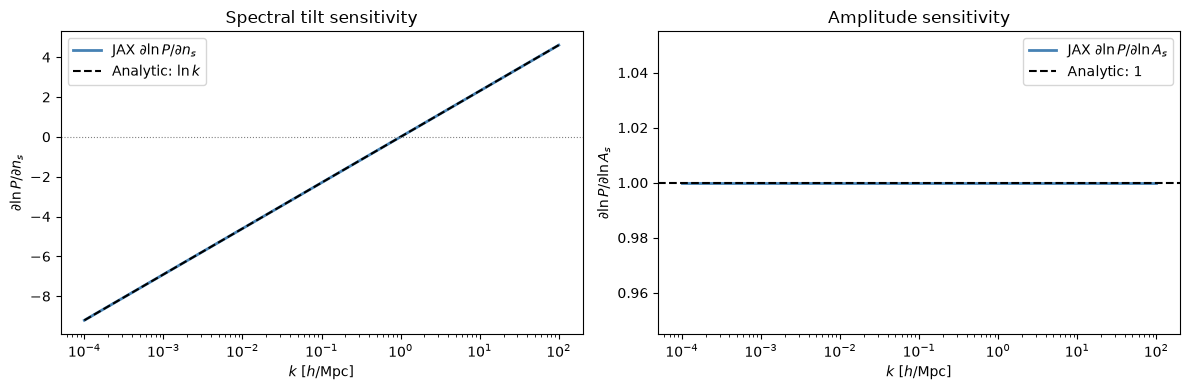

∂ln P/∂n_s      max|JAX − ln k| / |ln k| = 4.59e-16
∂ln P/∂ln A_s   max|JAX − 1|              = 2.22e-16


In [9]:
if _JAX:
    # ∂ ln P / ∂ n_s = ln k — spectral tilt derivative
    dlogP_dns_jax      = np.asarray(dPk_dns) / ps_nw.P(k, z=0)
    dlogP_dns_analytic = np.log(k)

    # ∂ ln P / ∂ ln A_s = 1 for all k (amplitude scaling)
    dlogP_dlnAs = jax.jacobian(
        lambda lnAs: jnp.log(Pk_jax(jnp.exp(lnAs), ns_ref))
    )(float(np.log(A_s_ref)))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    ax.semilogx(k, dlogP_dns_jax,      lw=2.0, color='steelblue',
                label=r'JAX $\partial \ln P / \partial n_s$')
    ax.semilogx(k, dlogP_dns_analytic, lw=1.5, ls='--', color='k',
                label=r'Analytic: $\ln k$')
    ax.axhline(0, color='gray', lw=0.8, ls=':')
    ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$')
    ax.set_ylabel(r'$\partial \ln P / \partial n_s$')
    ax.set_title('Spectral tilt sensitivity')
    ax.legend()

    ax = axes[1]
    ax.semilogx(k, np.asarray(dlogP_dlnAs), lw=2.0, color='steelblue',
                label=r'JAX $\partial \ln P / \partial \ln A_s$')
    ax.axhline(1.0, color='k', lw=1.5, ls='--', label='Analytic: 1')
    ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$')
    ax.set_ylabel(r'$\partial \ln P / \partial \ln A_s$')
    ax.set_title('Amplitude sensitivity')
    ax.legend()

    plt.tight_layout()
    plt.show()

    k_valid = (k > 1e-3) & (k < 50) & (np.abs(np.log(k)) > 0.1)
    print(f'∂ln P/∂n_s      max|JAX − ln k| / |ln k| = '
          f'{np.max(np.abs(dlogP_dns_jax[k_valid] - dlogP_dns_analytic[k_valid]) / np.abs(dlogP_dns_analytic[k_valid])):.2e}')
    print(f'∂ln P/∂ln A_s   max|JAX − 1|              = '
          f'{np.max(np.abs(np.asarray(dlogP_dlnAs) - 1.0)):.2e}')
else:
    print('JAX is not installed — skipping this autodiff demo.')

<a id="sec2-4"></a>
### 2.4. Autodiff II — all cosmological parameters

`pk_eh_nowiggle` removes the frozen-$T^2$ limitation: the σ₈ normalisation is a fixed-node log-k trapezoid (no `scipy.quad`) and the transfer function is backend-generic, so gradients flow through **every** parameter $(\Omega_m, \Omega_b, h_0, n_s, \sigma_8)$ in both jax and torch.

d(Σ P)/dθ — jax autodiff vs central finite differences:
  Om       jax = -2.443809e+05   FD = -2.443809e+05   rel err = 3.33e-10
  Ob       jax = +2.906465e+05   FD = +2.906465e+05   rel err = 1.67e-11
  h0       jax = -6.766339e+04   FD = -6.766339e+04   rel err = 1.69e-10
  ns       jax = -7.801591e+04   FD = -7.801591e+04   rel err = 1.13e-10
  sigma_8  jax = +7.824398e+04   FD = +7.824398e+04   rel err = 7.65e-12
torch autograd vs jax (all 5 params): max rel diff = 1.33e-15


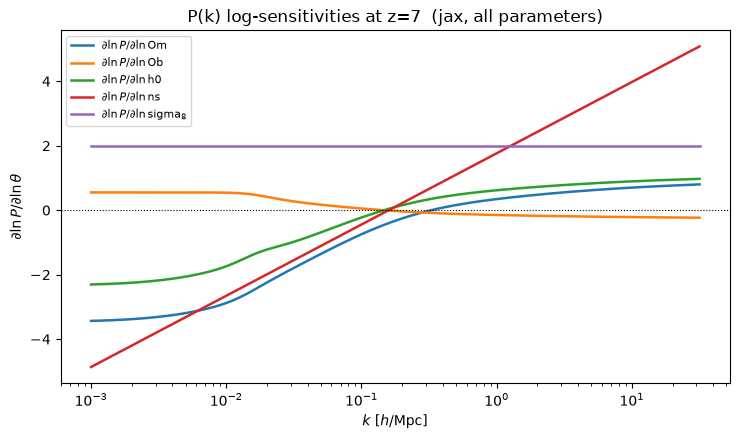

In [10]:
if _JAX:
    vec0  = jnp.asarray([theta0[n] for n in theta0])
    names = list(theta0)
    J = jax.jacobian(
        lambda v: pk_eh_nowiggle(jnp.asarray(k_grad), z_grad, *v, backend='jax').sum()
    )(vec0)

    print('d(Σ P)/dθ — jax autodiff vs central finite differences:')
    for i, n in enumerate(names):
        eps = 1e-5 * theta0[n]
        tp, tm = dict(theta0), dict(theta0)
        tp[n] += eps; tm[n] -= eps
        fd = (pk_eh_nowiggle(k_grad, z_grad, **tp).sum()
              - pk_eh_nowiggle(k_grad, z_grad, **tm).sum()) / (2 * eps)
        print(f'  {n:8s} jax = {float(J[i]):+.6e}   FD = {fd:+.6e}   '
              f'rel err = {abs(float(J[i]) / fd - 1):.2e}')

    if _TORCH_AVAILABLE:
        vec_t = torch.tensor([theta0[n] for n in names], dtype=torch.float64,
                             requires_grad=True)
        pk_eh_nowiggle(torch.as_tensor(k_grad), z_grad, *vec_t, backend='torch').sum().backward()
        rel = np.abs(vec_t.grad.numpy() / np.asarray(J) - 1)
        print(f'torch autograd vs jax (all 5 params): max rel diff = {rel.max():.2e}')
    else:
        print('torch is not installed — torch cross-check skipped.')

    # per-k log-sensitivities
    Jk = jax.jacobian(
        lambda v: jnp.log(pk_eh_nowiggle(jnp.asarray(k_grad), z_grad, *v, backend='jax'))
    )(vec0)
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    for i, n in enumerate(names):
        ax.semilogx(k_grad, np.asarray(Jk)[:, i] * theta0[n], lw=1.8,
                    label=fr'$\partial \ln P / \partial \ln \mathrm{{{n}}}$')
    ax.axhline(0, color='k', lw=0.8, ls=':')
    ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$')
    ax.set_ylabel(r'$\partial \ln P / \partial \ln \theta$')
    ax.set_title(f'P(k) log-sensitivities at z={z_grad:.0f}  (jax, all parameters)')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('JAX is not installed — skipping this autodiff demo.')

<a id="sec3"></a>
## 3. Growth factor D(z) and growth rate f₁

**Physics.** In linear theory every Fourier mode grows as $\delta(k, z) = D(z)\,\delta(k, 0)$ with
$D(a) \propto \Omega_m E(a) \int_0^a \mathrm{d}a' / (a' E(a'))^3$ for flat ΛCDM, and the growth *rate* $f_1 = \mathrm{d}\ln D/\mathrm{d}\ln a$ sets peculiar velocities and redshift-space distortions. BEoRN has two implementations: the numpy `beorn.cosmo.D` (default everywhere) and the backend-generic `beorn.cosmo.growth_factor` / `growth_rate` (differentiable, device-resident).

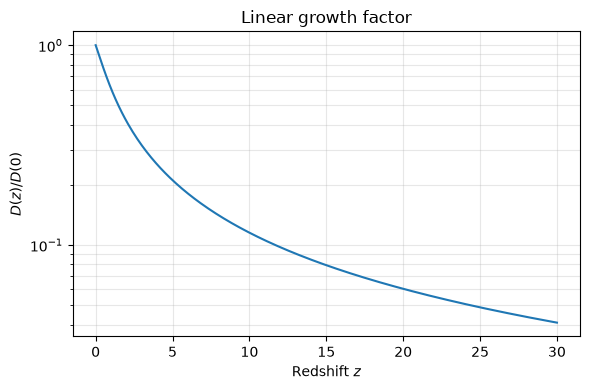

In [11]:
# Growth factor vs redshift (numpy default implementation)
zz = np.linspace(0, 30, 300)
aa = 1 / (1 + zz)
Dz = np.array([D(a, param) / D(1.0, param) for a in aa])

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(zz, Dz)
ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'$D(z)/D(0)$')
ax.set_title('Linear growth factor')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

<a id="sec3-1"></a>
### 3.1. Validation

The differentiable `growth_factor` against the numpy `cosmo.D` (expect ~10⁻⁴: 512 fixed nodes from $a'\to0$ vs numpy's 100 nodes from $a'=0.001$), and the autodiff growth rate against the Linder approximation $f_1 \simeq \Omega_m(z)^{0.55}$. The CAMB growth-ratio check ran in Section 2.1.

In [12]:
from beorn.cosmo import growth_factor, growth_rate

z_chk = 7.0
a_chk = 1.0 / (1.0 + z_chk)
D_np   = D(a_chk, param)
D_diff = float(growth_factor(a_chk, cosmo.Om))
f1_np  = float(growth_rate(a_chk, cosmo.Om))          # numpy: central FD
Om_z   = cosmo.Om * (1+z_chk)**3 / (cosmo.Om * (1+z_chk)**3 + 1 - cosmo.Om)
print(f'D(z={z_chk:.0f}):  numpy cosmo.D = {D_np:.6f}   growth_factor = {D_diff:.6f}   '
      f'rel diff = {abs(D_diff/D_np - 1):.2e}')
print(f'f1(z={z_chk:.0f}): growth_rate = {f1_np:.6f}   Linder Om(z)^0.55 = {Om_z**0.55:.6f}')

D(z=7):  numpy cosmo.D = 0.158551   growth_factor = 0.158545   rel diff = 3.64e-05
f1(z=7): growth_rate = 0.997691   Linder Om(z)^0.55 = 0.997672


<a id="sec3-2"></a>
### 3.2. GPU execution

Growth is a scalar integral — there is nothing to accelerate. The point of the backend version is *device-residency*: when D(z) is needed inside a GPU pipeline (LPT rescaling, HMF σ² scaling) it must not force a host round-trip.

In [13]:
if _TORCH_AVAILABLE and torch_gpu is not None:
    dtype_gpu = torch.float32 if torch_gpu == 'mps' else torch.float64
    Om_g = torch.tensor(cosmo.Om, dtype=dtype_gpu, device=torch_gpu)
    a_g  = torch.tensor(1.0 / (1.0 + 7.0), dtype=dtype_gpu, device=torch_gpu)
    D_g  = growth_factor(a_g, Om_g, backend='torch')
    print(f'growth_factor on torch {torch_gpu}: D(z=7) = {float(D_g):.6f}  '
          f'(device: {D_g.device})   numpy: {D(1/8, param):.6f}')
else:
    print('GPUs not available — growth stays on CPU (no throughput impact).')

growth_factor on torch cuda: D(z=7) = 0.158545  (device: cuda:0)   numpy: 0.158551


<a id="sec3-3"></a>
### 3.3. Autodiff

$\partial D/\partial \Omega_m$ by jax autodiff vs finite differences, the exact autodiff growth rate $f_1$ (replacing the numeric central difference used elsewhere), and the sensitivity $\partial D(z)/\partial\Omega_m$ across redshift.

dD/dOm at z=7:  jax = -1.152582e-01   FD = -1.152582e-01   rel err = 5.76e-10
f1 by exact autodiff: 0.997691
f1 by torch autograd: 0.997691   (jax vs torch rel diff = 0.00e+00)


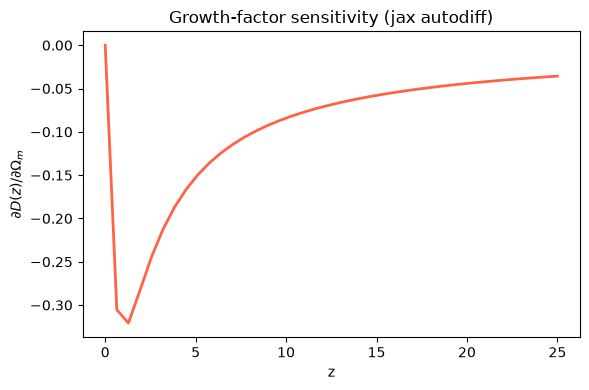

In [14]:
if _JAX:
    a_grad = 1.0 / (1.0 + 7.0)
    dD_dOm = jax.grad(lambda Om: growth_factor(a_grad, Om, backend='jax'))(cosmo.Om)
    eps = 1e-5
    fd_D = (growth_factor(a_grad, cosmo.Om + eps) - growth_factor(a_grad, cosmo.Om - eps)) / (2 * eps)
    f1_jax = growth_rate(a_grad, cosmo.Om, backend='jax')
    print(f'dD/dOm at z=7:  jax = {float(dD_dOm):+.6e}   FD = {fd_D:+.6e}   '
          f'rel err = {abs(float(dD_dOm)/fd_D - 1):.2e}')
    print(f'f1 by exact autodiff: {float(f1_jax):.6f}')
    if _TORCH_AVAILABLE:
        f1_t = growth_rate(a_grad, cosmo.Om, backend='torch')
        print(f'f1 by torch autograd: {float(f1_t):.6f}   '
              f'(jax vs torch rel diff = {abs(float(f1_jax)/float(f1_t) - 1):.2e})')

    zz_g = np.linspace(0, 25, 40)
    dD = [float(jax.grad(lambda Om: growth_factor(1/(1+zi), Om, backend='jax'))(cosmo.Om))
          for zi in zz_g]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(zz_g, dD, lw=2, color='tomato')
    ax.set_xlabel('z')
    ax.set_ylabel(r'$\partial D(z) / \partial \Omega_m$')
    ax.set_title('Growth-factor sensitivity (jax autodiff)')
    plt.tight_layout()
    plt.show()
else:
    print('JAX is not installed — skipping this autodiff demo.')

<a id="sec4"></a>
## 4. Halo mass function

**Physics.** The abundance of collapsed halos follows from the statistics of the smoothed linear density field: $\sigma^2(M)$ is the variance in spheres containing mass $M$, and the mass function is
$\mathrm{d}n/\mathrm{d}\ln M = (\bar\rho_m / M)\,|\mathrm{d}\ln\sigma/\mathrm{d}\ln M|\,f(\nu)$ with peak height $\nu = \delta_c^2/\sigma^2$. All parametric models share
$f(\nu) = A\sqrt{2 q \nu/\pi}\,(1 + (q\nu)^{-p})\,e^{-q\nu/2}$: Press-Schechter $(A, p, q) = (0.5, 0, 1)$, Sheth-Tormen $(0.322, 0.3, 0.707)$, ellipsoidal $(0.322, 0.3, 1)$.

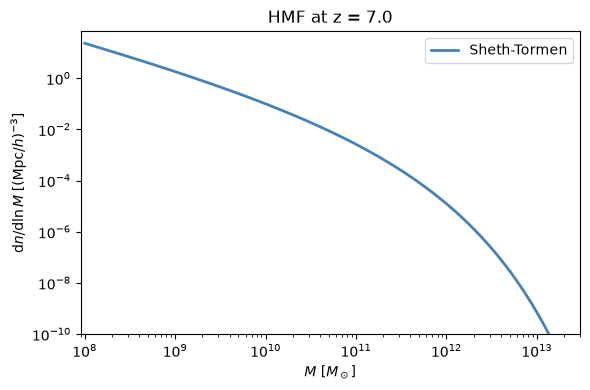

In [15]:
hmf = HaloMassFunction(param)           # ST, tophat, numpy
n   = hmf.dndlnm(M, z=z)

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(M, n, lw=2, color='steelblue', label='Sheth-Tormen')
ax.set_xlabel(r'$M\ [M_\odot]$')
ax.set_ylabel(r'$\mathrm{d}n / \mathrm{d}\ln M\;[(\mathrm{Mpc}/h)^{-3}]$')
ax.set_title(f'HMF at z = {z}')
ax.set_ylim(1e-10, 70)
ax.set_xlim(9e7, 3e13)
ax.legend()
plt.tight_layout()
plt.show()

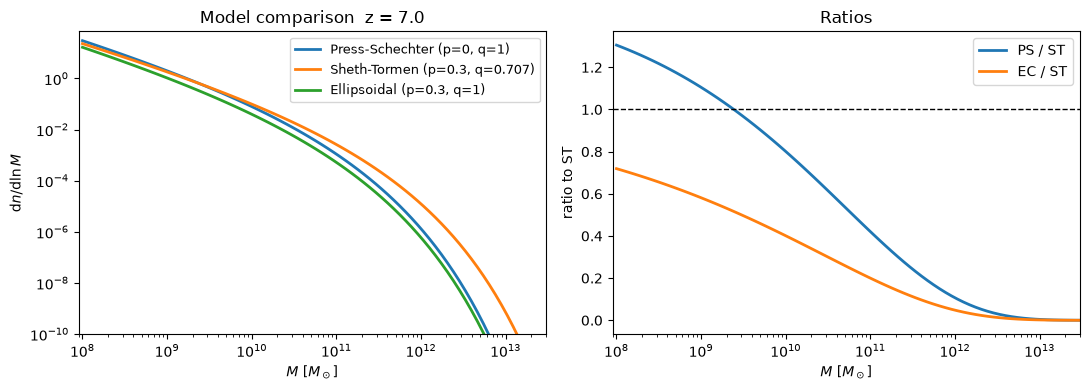

In [16]:
n_ps = hmf.run_press_schechter(M, z)
n_st = hmf.run_sheth_tormen(M, z)
n_ec = hmf.run_ellipsoidal(M, z)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.loglog(M, n_ps, lw=2, label='Press-Schechter (p=0, q=1)')
ax.loglog(M, n_st, lw=2, label='Sheth-Tormen (p=0.3, q=0.707)')
ax.loglog(M, n_ec, lw=2, label='Ellipsoidal (p=0.3, q=1)')
ax.set_xlabel(r'$M\ [M_\odot]$')
ax.set_ylabel(r'$\mathrm{d}n/\mathrm{d}\ln M$')
ax.set_title(f'Model comparison  z = {z}')
ax.set_ylim(1e-10, 70)
ax.set_xlim(9e7, 3e13)
ax.legend(fontsize=9)

ax = axes[1]
ax.semilogx(M, n_ps / n_st, lw=2, label='PS / ST')
ax.semilogx(M, n_ec / n_st, lw=2, label='EC / ST')
ax.axhline(1, color='k', lw=1, ls='--')
ax.set_xlabel(r'$M\ [M_\odot]$')
ax.set_ylabel('ratio to ST')
ax.set_title('Ratios')
ax.set_xlim(9e7, 3e13)
ax.legend()

plt.tight_layout()
plt.show()

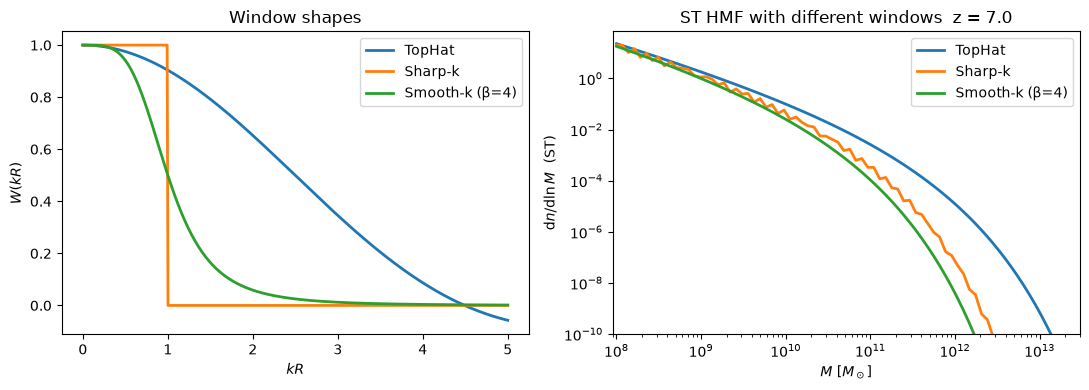

In [17]:
hmf_th  = HaloMassFunction(param, window='tophat')
hmf_sk  = HaloMassFunction(param, window='sharp_k')
hmf_smk = HaloMassFunction(param, window='smooth_k')   # beta=4

n_th  = hmf_th.dndlnm(M, z)
n_sk  = hmf_sk.dndlnm(M, z)
n_smk = hmf_smk.dndlnm(M, z)

# -- window shapes --
from beorn.mass_function import TopHatWindow, SharpKWindow, SmoothKWindow
x = np.linspace(0, 5, 500)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(x, TopHatWindow().W(x),  lw=2, label='TopHat')
ax.plot(x, SharpKWindow().W(x),  lw=2, label='Sharp-k')
ax.plot(x, SmoothKWindow().W(x), lw=2, label='Smooth-k (β=4)')
ax.set_xlabel(r'$kR$')
ax.set_ylabel(r'$W(kR)$')
ax.set_title('Window shapes')
ax.legend()

ax = axes[1]
ax.loglog(M, n_th,  lw=2, label='TopHat')
ax.loglog(M, n_sk,  lw=2, label='Sharp-k')
ax.loglog(M, n_smk, lw=2, label='Smooth-k (β=4)')
ax.set_xlabel(r'$M\ [M_\odot]$')
ax.set_ylabel(r'$\mathrm{d}n/\mathrm{d}\ln M$  (ST)')
ax.set_title(f'ST HMF with different windows  z = {z}')
ax.set_ylim(1e-10, 70)
ax.set_xlim(9e7, 3e13)
ax.legend()

plt.tight_layout()
plt.show()

In [18]:
hmf_base = HaloMassFunction(param)   # single sigma^2 precomputation

for z_run in [6.0, 8.0, 10.0]:
    n_ps_z = hmf_base.run_press_schechter(M, z_run)
    n_st_z = hmf_base.run_sheth_tormen(M, z_run)
    print(f'z={z_run:.0f}  n(>1e10 Msun) PS={np.sum(n_ps_z[M>=1e10])*dlnM:.3e}  '
          f'ST={np.sum(n_st_z[M>=1e10])*dlnM:.3e}  (Mpc/h)^-3')

# Custom (p, q) via dndlnm overrides
n_custom = hmf_base.dndlnm(M, z, p=0.2, q=0.8)
print(f'Custom (p=0.2, q=0.8)  n(>1e10)={np.sum(n_custom[M>=1e10])*dlnM:.3e}')

z=6  n(>1e10 Msun) PS=1.009e-01  ST=1.146e-01  (Mpc/h)^-3
z=8  n(>1e10 Msun) PS=1.694e-02  ST=3.209e-02  (Mpc/h)^-3
z=10  n(>1e10 Msun) PS=1.737e-03  ST=6.307e-03  (Mpc/h)^-3
Custom (p=0.2, q=0.8)  n(>1e10)=4.870e-02


<a id="sec4-1"></a>
### 4.1. Validation against colossus

If `colossus` is installed, compare Press-Schechter and Sheth-Tormen against its implementations — both with BEoRN's E&H spectrum and with the colossus P(k) injected through `TabulatedPowerSpectrum` (isolates the P(k) difference from the f(ν) difference).

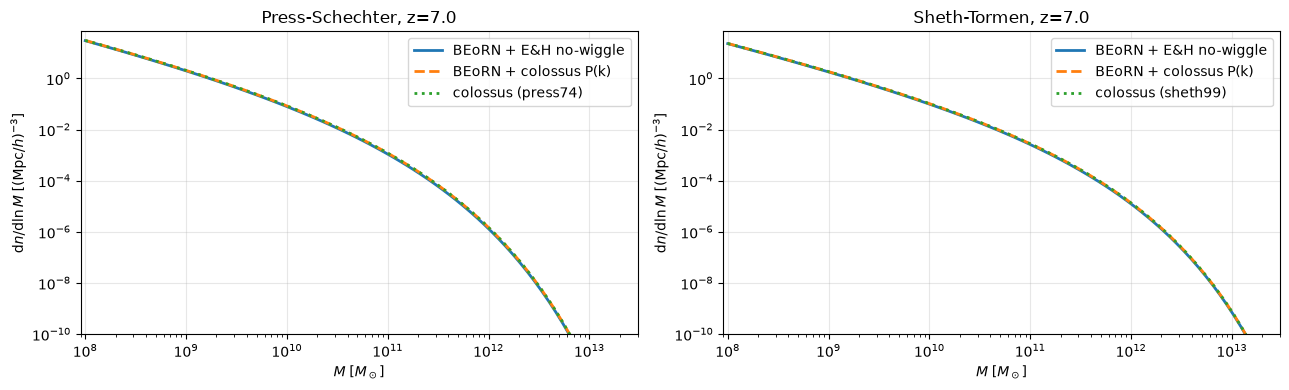

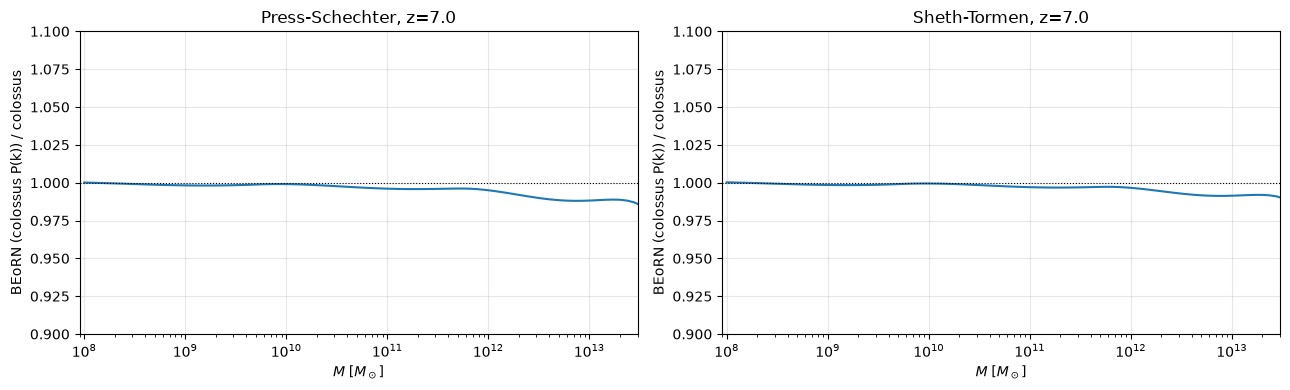

In [19]:
try:
    from colossus.cosmology import cosmology as col_cosmo
    from colossus.lss import mass_function as col_mf
    _COLOSSUS_AVAILABLE = True
except ImportError:
    _COLOSSUS_AVAILABLE = False
    print('colossus not installed — skipping comparison.')
    print('Install: pip install colossus')

if _COLOSSUS_AVAILABLE:
    from beorn.lpt import TabulatedPowerSpectrum

    # Set up colossus cosmology to match BEoRN param
    h = param.cosmology.h0
    cosmo_col = col_cosmo.setCosmology('planck18')
    cosmo_col = col_cosmo.setCosmology('custom', {
        'flat': True,
        'H0':   100 * h,
        'Om0':  param.cosmology.Om,
        'Ob0':  param.cosmology.Ob,
        'sigma8': param.cosmology.sigma_8,
        'ns':   param.cosmology.ns,
    })

    M_arr = M   # use the mass array from the setup cell

    # Build a dense k grid and evaluate the colossus power spectrum
    k_tab = np.logspace(-4, 2, 800)
    Pk_tab = np.array([cosmo_col.matterPowerSpectrum(ki, z=0) for ki in k_tab])

    # Wrap it in TabulatedPowerSpectrum — renormalize=True rescales so that
    # sigma_8 computed from this table exactly matches param.cosmology.sigma_8
    ps_col = TabulatedPowerSpectrum(param, k_tab, Pk_tab, renormalize=True)

    # Build HMF with the colossus P(k) — uses BEoRN growth factor for z evolution
    hmf_col = HaloMassFunction(param, ps_method='tabulated', k=k_tab, Pk=Pk_tab)

    models_cmp = [
        ('press_schechter', 'press74', 'Press-Schechter'),
        ('sheth_tormen',    'sheth99', 'Sheth-Tormen'),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, (beorn_model, col_model, label) in zip(axes, models_cmp):
        hmf_beorn_eh  = HaloMassFunction(param, model=beorn_model)         # E&H no-wiggle
        hmf_beorn_col = HaloMassFunction(param, model=beorn_model,
                                         ps_method='tabulated',
                                         k=k_tab, Pk=Pk_tab)               # colossus P(k)

        n_eh  = hmf_beorn_eh.dndlnm(M_arr, z=z)
        n_tab = hmf_beorn_col.dndlnm(M_arr, z=z)
        n_col = col_mf.massFunction(M_arr * h, z=z, mdef='fof',
                                    model=col_model, q_in='M', q_out='dndlnM')

        ax.loglog(M_arr, n_eh,  lw=2,          label='BEoRN + E&H no-wiggle')
        ax.loglog(M_arr, n_tab, lw=2, ls='--',  label='BEoRN + colossus P(k)')
        ax.loglog(M_arr, n_col, lw=2, ls=':',   label=f'colossus ({col_model})')
        ax.set_xlabel(r'$M\;[M_\odot]$')
        ax.set_ylabel(r'$\mathrm{d}n/\mathrm{d}\ln M\;[(\mathrm{Mpc}/h)^{-3}]$')
        ax.set_title(f'{label}, z={z}')
        ax.legend(); ax.grid(True, alpha=0.3)
        ax.set_ylim(1e-10, 70)
        ax.set_xlim(9e7, 3e13)
    plt.tight_layout(); plt.show()

    # Ratio plot
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, (beorn_model, col_model, label) in zip(axes, models_cmp):
        hmf_beorn_col = HaloMassFunction(param, model=beorn_model,
                                         ps_method='tabulated',
                                         k=k_tab, Pk=Pk_tab)
        n_tab = hmf_beorn_col.dndlnm(M_arr, z=z)
        n_col = col_mf.massFunction(M_arr * h, z=z, mdef='fof',
                                    model=col_model, q_in='M', q_out='dndlnM')
        mask = n_col > 0
        ax.semilogx(M_arr[mask], n_tab[mask] / n_col[mask])
        ax.axhline(1, color='k', lw=0.8, ls=':')
        ax.set_xlabel(r'$M\;[M_\odot]$')
        ax.set_ylabel('BEoRN (colossus P(k)) / colossus')
        ax.set_title(f'{label}, z={z}')
        ax.set_ylim(0.9, 1.1); ax.grid(True, alpha=0.3)
        ax.set_xlim(9e7, 3e13)
    plt.tight_layout(); plt.show()
else:
    print('colossus not available — install with: pip install colossus')

<a id="sec4-2"></a>
### 4.2. GPU and backend accuracy/speed

The differentiable core $f(\nu)$ is device-agnostic — it runs on whatever device its input lives on. `dndlnm` end-to-end is currently CPU-bound (its constant arrays are created on host). MPS caveat: float32 only, and $e^{-q\nu/2}$ underflows float32 for $\nu \gtrsim 200$ (the rare-massive-halo tail, $f < 10^{-30}$), so accuracy is compared where $f$ is float32-representable.

In [20]:
hmf_np = HaloMassFunction(param, backend='numpy')
n_ref  = hmf_np.dndlnm(M, z)
dc_ref, p_ref, q_ref = 1.686, 0.3, 0.707

rows = [('numpy cpu float64 (reference)', 0.0)]
if _JAX:
    hmf_jax = HaloMassFunction(param, backend='jax')
    rows.append(('jax dndlnm (x64)',
                 float(np.max(np.abs(np.asarray(hmf_jax.dndlnm(M, z)) / n_ref - 1)))))
else:
    print('JAX is not installed — jax accuracy row skipped.')
if _TORCH_AVAILABLE:
    hmf_torch = HaloMassFunction(param, backend='torch')
    rows.append(('torch cpu dndlnm (float64)',
                 float(np.max(np.abs(hmf_torch.dndlnm(M, z).numpy() / n_ref - 1)))))
else:
    print('torch is not installed — torch accuracy rows skipped.')

# GPU: f(nu) kernel on the device of its input tensor
nu_np = (dc_ref / np.sqrt(hmf_np.sigma2(M, z))) ** 2
f_ref = hmf_np.f_nu(nu_np)
if _TORCH_AVAILABLE and torch_gpu is not None:
    dtype_gpu = torch.float32 if torch_gpu == 'mps' else torch.float64
    nu_gpu = torch.as_tensor(nu_np, dtype=dtype_gpu, device=torch_gpu)
    f_gpu  = hmf_torch.f_nu(nu_gpu).cpu().double().numpy()
    valid  = f_ref > 1e-30
    rows.append((f'torch {torch_gpu} f_nu ({str(dtype_gpu).split(".")[-1]}, f>1e-30)',
                 float(np.max(np.abs(f_gpu[valid] / f_ref[valid] - 1)))))
else:
    print('GPUs not available — GPU accuracy row skipped.')

print('\nAccuracy vs numpy float64:')
for name, err in rows:
    print(f'  {name:44s} max|ratio−1| = {err:.2e}')


Accuracy vs numpy float64:
  numpy cpu float64 (reference)                max|ratio−1| = 0.00e+00
  jax dndlnm (x64)                             max|ratio−1| = 4.44e-16
  torch cpu dndlnm (float64)                   max|ratio−1| = 4.44e-16
  torch cuda f_nu (float64, f>1e-30)           max|ratio−1| = 2.22e-16


In [21]:
# ── Speed: f(nu) kernel on a large array, CPU vs GPU ─────────────────────────
N_bench = 2**24                                   # ~16.8M values (134 MB float64)
nu_big  = np.random.RandomState(1).uniform(0.1, 8.0, N_bench)

results = {}
results['numpy  cpu float64'] = bench(lambda: hmf_np.f_nu(nu_big))
results['numpy  cpu float32'] = bench(lambda: hmf_np.f_nu(nu_big.astype(np.float32)))

if _JAX:
    nu_j  = jnp.asarray(nu_big)
    f_jit = jax.jit(hmf_jax.f_nu)
    results[f'jax    {jax.devices()[0].platform} jit float64'] = bench(
        lambda: f_jit(nu_j).block_until_ready())
else:
    print('JAX is not installed — jax timing skipped.')

if _TORCH_AVAILABLE:
    nu_t = torch.as_tensor(nu_big)
    results['torch  cpu float64'] = bench(lambda: hmf_torch.f_nu(nu_t))
    if torch_gpu is not None:
        dtype_gpu = torch.float32 if torch_gpu == 'mps' else torch.float64
        nu_g = torch.as_tensor(nu_big, dtype=dtype_gpu, device=torch_gpu)
        sync = torch.mps.synchronize if torch_gpu == 'mps' else torch.cuda.synchronize
        def _run_gpu():
            hmf_torch.f_nu(nu_g); sync()
        results[f'torch  {torch_gpu} {str(dtype_gpu).split(".")[-1]}'] = bench(_run_gpu)
    else:
        print('GPUs not available — GPU timing skipped.')
else:
    print('torch is not installed — torch timings skipped.')

t_ref = results['numpy  cpu float64']
print(f'\nf(nu) kernel, {N_bench:.2e} values (best of 5):')
for name, t in sorted(results.items(), key=lambda kv: kv[1]):
    print(f'  {name:30s} {t*1e3:8.1f} ms   speedup: {t_ref/t:4.1f}× faster than numpy float64')

# dndlnm end-to-end (CPU-bound: constant arrays built on host each call)
M_big = np.logspace(8, 15, 500_000)
print(f'\ndndlnm end-to-end, {M_big.size:.0e} masses (σ² interpolation + f(ν)):')
print(f'  numpy  {bench(lambda: hmf_np.dndlnm(M_big, z), n=3)*1e3:8.1f} ms')
if _JAX:
    print(f'  jax    {bench(lambda: np.asarray(hmf_jax.dndlnm(M_big, z)), n=3)*1e3:8.1f} ms')
if _TORCH_AVAILABLE:
    print(f'  torch  {bench(lambda: hmf_torch.dndlnm(M_big, z).numpy(), n=3)*1e3:8.1f} ms')
print('  (GPU cannot accelerate this path until _to_backend gains a device'
      ' argument)')


f(nu) kernel, 1.68e+07 values (best of 5):
  jax    gpu jit float64              0.3 ms   speedup: 1107.6× faster than numpy float64
  torch  cuda float64                 1.0 ms   speedup: 310.0× faster than numpy float64
  torch  cpu float64                 26.3 ms   speedup: 11.8× faster than numpy float64
  numpy  cpu float32                189.2 ms   speedup:  1.6× faster than numpy float64
  numpy  cpu float64                308.7 ms   speedup:  1.0× faster than numpy float64

dndlnm end-to-end, 5e+05 masses (σ² interpolation + f(ν)):
  numpy      59.4 ms
  jax        52.4 ms
  torch      56.0 ms
  (GPU cannot accelerate this path until _to_backend gains a device argument)


<a id="sec4-3"></a>
### 4.3. Autodiff I — shape parameters (δ_c, p, q)

σ²(M) is a frozen table here, so gradients flow through the collapse threshold and the f(ν) shape parameters only — the classic use case: how does the halo abundance respond to the collapse physics? jax first, then the same gradients with torch autograd.

In [22]:
if _JAX:
    # n(>Mmin) = sum_M  dn/dlnM * dlnM
    def n_total_jax(delta_c):
        return hmf_jax.dndlnm(M, z, delta_c=delta_c).sum() * dlnM

    def n_total_p(p):
        return hmf_jax.dndlnm(M, z, p=p).sum() * dlnM

    def n_total_q(q):
        return hmf_jax.dndlnm(M, z, q=q).sum() * dlnM

    dc_ref, p_ref, q_ref = 1.686, 0.3, 0.707

    dn_dc = jax.grad(n_total_jax)(dc_ref)
    dn_dp = jax.grad(n_total_p)(p_ref)
    dn_dq = jax.grad(n_total_q)(q_ref)

    print(f'dn(>Mmin)/d(delta_c) = {float(dn_dc):.4e}  [(Mpc/h)^-3]')
    print(f'dn(>Mmin)/d(p)       = {float(dn_dp):.4e}  [(Mpc/h)^-3]')
    print(f'dn(>Mmin)/d(q)       = {float(dn_dq):.4e}  [(Mpc/h)^-3]')

    # Finite-difference check
    eps_fd = 1e-4
    dn_dc_fd = (n_total_jax(dc_ref + eps_fd) - n_total_jax(dc_ref - eps_fd)) / (2 * eps_fd)
    print(f'\nFinite-diff dn/d(delta_c) = {float(dn_dc_fd):.4e}')
    print(f'Relative error vs JAX grad = {abs(float(dn_dc - dn_dc_fd)/float(dn_dc_fd)):.2e}')
else:
    print('JAX is not installed — skipping this autodiff demo.')

dn(>Mmin)/d(delta_c) = -2.4675e+01  [(Mpc/h)^-3]
dn(>Mmin)/d(p)       = -9.1287e+00  [(Mpc/h)^-3]
dn(>Mmin)/d(q)       = -2.9421e+01  [(Mpc/h)^-3]

Finite-diff dn/d(delta_c) = -2.4675e+01
Relative error vs JAX grad = 3.89e-09


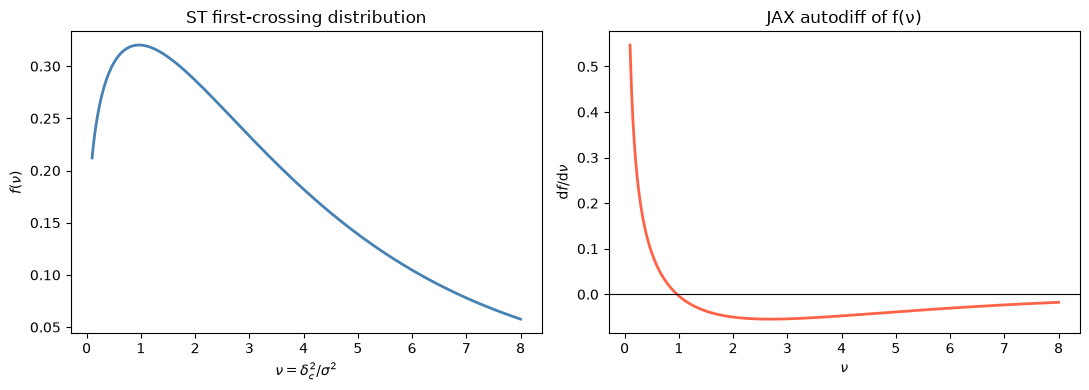

In [23]:
if _JAX:
    # df/dnu — derivative of the first-crossing distribution
    nu_arr = jnp.linspace(0.1, 8.0, 300)

    # ST f(nu) and its derivative
    f_arr   = hmf_jax.f_nu(nu_arr)
    df_dnu  = jax.vmap(jax.grad(lambda nu: hmf_jax.f_nu(jnp.array([nu]))[0]))(nu_arr)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    ax = axes[0]
    ax.plot(nu_arr, f_arr,  lw=2, color='steelblue', label=r'$f(\nu)$')
    ax.set_xlabel(r'$\nu = \delta_c^2 / \sigma^2$')
    ax.set_ylabel(r'$f(\nu)$')
    ax.set_title('ST first-crossing distribution')

    ax = axes[1]
    ax.plot(nu_arr, df_dnu, lw=2, color='tomato',    label=r'$\mathrm{d}f/\mathrm{d}\nu$ (JAX)')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xlabel(r'$\nu$')
    ax.set_ylabel(r'$\mathrm{d}f/\mathrm{d}\nu$')
    ax.set_title('JAX autodiff of f(ν)')

    plt.tight_layout()
    plt.show()
else:
    print('JAX is not installed — skipping this autodiff demo.')

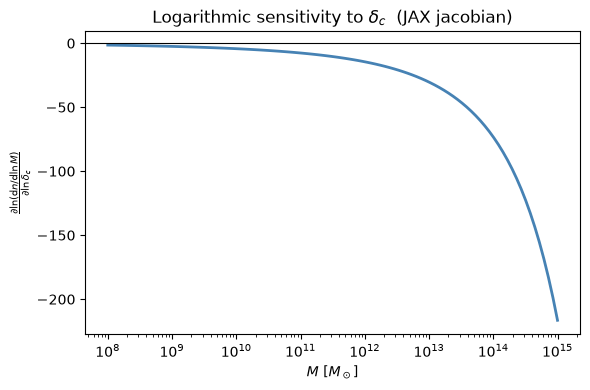

In [24]:
if _JAX:
    # Sensitivity of the HMF to delta_c at every mass bin
    grad_per_bin = jax.jacobian(lambda dc: hmf_jax.dndlnm(M, z, delta_c=dc))(dc_ref)
    # grad_per_bin[i] = d(dndlnM[i]) / d(delta_c)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.semilogx(M, np.asarray(grad_per_bin) * dc_ref / n_ref,
                lw=2, color='steelblue')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xlabel(r'$M\ [M_\odot]$')
    ax.set_ylabel(r'$\frac{\partial \ln(\mathrm{d}n/\mathrm{d}\ln M)}{\partial \ln\delta_c}$')
    ax.set_title(r'Logarithmic sensitivity to $\delta_c$  (JAX jacobian)')
    plt.tight_layout()
    plt.show()
else:
    print('JAX is not installed — skipping this autodiff demo.')

In [25]:
if _TORCH_AVAILABLE:
    # Gradient w.r.t. multiple parameters simultaneously (torch jacobian)
    def hmf_output(dc, p, q):
        return hmf_torch.dndlnm(M, z, delta_c=dc, p=float(p), q=float(q))

    dc_t = torch.tensor(dc_ref, dtype=torch.float64, requires_grad=True)
    p_t  = torch.tensor(p_ref,  dtype=torch.float64, requires_grad=True)
    q_t  = torch.tensor(q_ref,  dtype=torch.float64, requires_grad=True)

    # Gradient of total count w.r.t. each parameter
    n_out = hmf_torch.dndlnm(M, z, delta_c=dc_t, p=p_t, q=q_t).sum() * dlnM
    n_out.backward()

    print(f'dn/d(delta_c) = {dc_t.grad.item():.4e}')
    print(f'dn/d(p)       = {p_t.grad.item():.4e}')
    print(f'dn/d(q)       = {q_t.grad.item():.4e}')
    if _JAX:
        print(f'\ncross-check dn/d(delta_c):  jax = {float(dn_dc):.4e}   '
              f'torch vs jax rel diff = {abs(dc_t.grad.item() - float(dn_dc)) / abs(float(dn_dc)):.2e}')
else:
    print('torch is not installed — skipping torch autograd demo.')

dn/d(delta_c) = -2.4675e+01
dn/d(p)       = -9.1287e+00
dn/d(q)       = -2.9421e+01

cross-check dn/d(delta_c):  jax = -2.4675e+01   torch vs jax rel diff = 2.88e-16


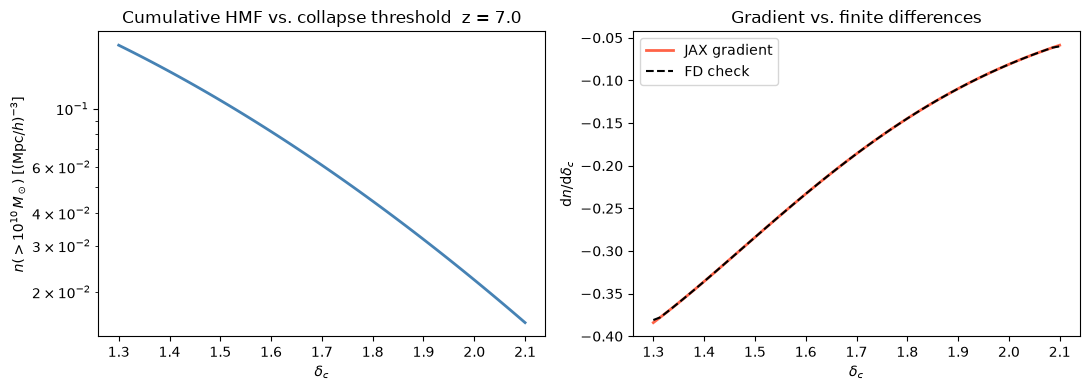

In [26]:
if _JAX:
    # Sweep: how does n(>1e10 Msun) change as delta_c varies?
    dc_vals = np.linspace(1.3, 2.1, 60)

    if _TORCH_AVAILABLE:
        n_vals = np.array([
            float(hmf_torch.dndlnm(M[M >= 1e10], z, delta_c=float(dc)).sum() * dlnM)
            for dc in dc_vals
        ])
    else:
        # Fall back to numpy HMF for the sweep when torch is unavailable
        _hmf_np = HaloMassFunction(param, backend='numpy')
        n_vals = np.array([
            float(_hmf_np.dndlnm(M[M >= 1e10], z, delta_c=float(dc)).sum() * dlnM)
            for dc in dc_vals
        ])

    # JAX gradient at each delta_c
    grad_vals = np.array([
        float(jax.grad(lambda dc: hmf_jax.dndlnm(M[M >= 1e10], z, delta_c=dc).sum() * dlnM)(float(dc)))
        for dc in dc_vals
    ])

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    ax = axes[0]
    ax.semilogy(dc_vals, n_vals, lw=2, color='steelblue')
    ax.set_xlabel(r'$\delta_c$')
    ax.set_ylabel(r'$n(>10^{10}\,M_\odot)\;[(\mathrm{Mpc}/h)^{-3}]$')
    ax.set_title(f'Cumulative HMF vs. collapse threshold  z = {z}')

    ax = axes[1]
    ax.plot(dc_vals, grad_vals, lw=2, color='tomato', label='JAX gradient')
    # Finite-difference check
    fd_grad = np.gradient(n_vals, dc_vals)
    ax.plot(dc_vals, fd_grad, lw=1.5, ls='--', color='k', label='FD check')
    ax.set_xlabel(r'$\delta_c$')
    ax.set_ylabel(r'$\mathrm{d}n/\mathrm{d}\delta_c$')
    ax.set_title('Gradient vs. finite differences')
    ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print('JAX is not installed — skipping this autodiff demo.')

<a id="sec4-4"></a>
### 4.4. Autodiff II — cosmology parameters

`beorn.mass_function.dndlnm_diff` removes the frozen-σ² limitation: σ²(M) is a direct backend integral over the differentiable P(k), and dlnσ/dlnM is **analytic** (top-hat dW/dx) rather than the classes' 1% finite difference — that finite-difference error is exactly why the parity below is ~10⁻³–10⁻² (largest at the extreme-mass end, where σ is smallest) while σ² itself agrees to ~10⁻⁴. Gradients flow through all eight parameters. (With `A=None` the self-consistent A(p) uses a float p — pass explicit `A` when differentiating w.r.t. p.)

In [27]:
from beorn.mass_function import dndlnm_diff, sigma2_M

theta_h = dict(Om=cosmo.Om, Ob=cosmo.Ob, h0=cosmo.h0, ns=cosmo.ns,
               sigma_8=cosmo.sigma_8, p=0.3, q=0.707, delta_c=1.686)
A_st = 0.3222
names_h = list(theta_h)

n_ref_h = HaloMassFunction(param).dndlnm(M, z)
n_new_h = dndlnm_diff(M, z, A=A_st, **theta_h)
print(f'dndlnm_diff vs class: max|ratio-1| = {np.max(np.abs(n_new_h/n_ref_h-1)):.2e}'
      '   (class uses 1% FD for dln sigma/dlnM; sigma^2 agrees to ~1e-4)')

if _JAX:
    def n_jax_h(vec):
        d = dict(zip(names_h, vec))
        return dndlnm_diff(jnp.asarray(M), z, d['Om'], d['Ob'], d['h0'], d['ns'],
                           d['sigma_8'], p=d['p'], q=d['q'], delta_c=d['delta_c'],
                           A=A_st, backend='jax').sum()
    vec0_h = jnp.asarray([theta_h[n] for n in names_h])
    J_h = jax.jacobian(n_jax_h)(vec0_h)
    print('\nd(Σ dn/dlnM)/dθ — jax autodiff vs central finite differences:')
    for i, n in enumerate(names_h):
        eps = 1e-5 * abs(theta_h[n])
        tp, tm = dict(theta_h), dict(theta_h)
        tp[n] += eps; tm[n] -= eps
        fd = (dndlnm_diff(M, z, A=A_st, **tp).sum()
              - dndlnm_diff(M, z, A=A_st, **tm).sum()) / (2 * eps)
        print(f'  {n:8s} jax = {float(J_h[i]):+.6e}   FD = {fd:+.6e}   '
              f'rel err = {abs(float(J_h[i])/fd - 1):.2e}')
else:
    print('JAX is not installed — jax gradient table skipped.')

if _TORCH_AVAILABLE and _JAX:
    vec_t = torch.tensor([theta_h[n] for n in names_h], dtype=torch.float64,
                         requires_grad=True)
    d = dict(zip(names_h, vec_t))
    dndlnm_diff(torch.as_tensor(M), z, d['Om'], d['Ob'], d['h0'], d['ns'],
                d['sigma_8'], p=d['p'], q=d['q'], delta_c=d['delta_c'],
                A=A_st, backend='torch').sum().backward()
    rel = np.abs(vec_t.grad.numpy() / np.asarray(J_h) - 1)
    print(f'\ntorch autograd vs jax (all 8 params): max rel diff = {rel.max():.2e}')
elif not _TORCH_AVAILABLE:
    print('torch is not installed — torch cross-check skipped.')

if _TORCH_AVAILABLE and torch_gpu is not None:
    dtype_gpu = torch.float32 if torch_gpu == 'mps' else torch.float64
    Mt = torch.as_tensor(M, dtype=dtype_gpu, device=torch_gpu)
    args = [torch.tensor(theta_h[n], dtype=dtype_gpu, device=torch_gpu)
            for n in ['Om', 'Ob', 'h0', 'ns', 'sigma_8']]
    n_gpu = dndlnm_diff(Mt, z, *args, p=0.3, q=0.707, A=A_st, delta_c=1.686,
                        backend='torch').cpu().double().numpy()
    valid = n_ref_h > 1e-30
    print(f'torch {torch_gpu} dndlnm_diff: max|ratio-1| vs class (n>1e-30) = '
          f'{np.max(np.abs(n_gpu[valid]/n_ref_h[valid]-1)):.2e}')
else:
    print('GPUs not available — GPU dndlnm_diff test skipped.')

dndlnm_diff vs class: max|ratio-1| = 7.84e-03   (class uses 1% FD for dln sigma/dlnM; sigma^2 agrees to ~1e-4)

d(Σ dn/dlnM)/dθ — jax autodiff vs central finite differences:
  Om       jax = +8.105865e+02   FD = +8.105865e+02   rel err = 6.60e-10
  Ob       jax = -6.562069e+02   FD = -6.562069e+02   rel err = 1.13e-10
  h0       jax = -4.668808e+01   FD = -4.668808e+01   rel err = 1.44e-08
  ns       jax = +6.574326e+02   FD = +6.574326e+02   rel err = 2.41e-10
  sigma_8  jax = +3.078764e+02   FD = +3.078764e+02   rel err = 3.06e-11
  p        jax = -5.607127e+01   FD = -5.607127e+01   rel err = 2.96e-11
  q        jax = -1.807195e+02   FD = -1.807195e+02   rel err = 2.82e-12
  delta_c  jax = -1.515643e+02   FD = -1.515643e+02   rel err = 1.14e-10

torch autograd vs jax (all 8 params): max rel diff = 6.07e-13
torch cuda dndlnm_diff: max|ratio-1| vs class (n>1e-30) = 4.12e-03


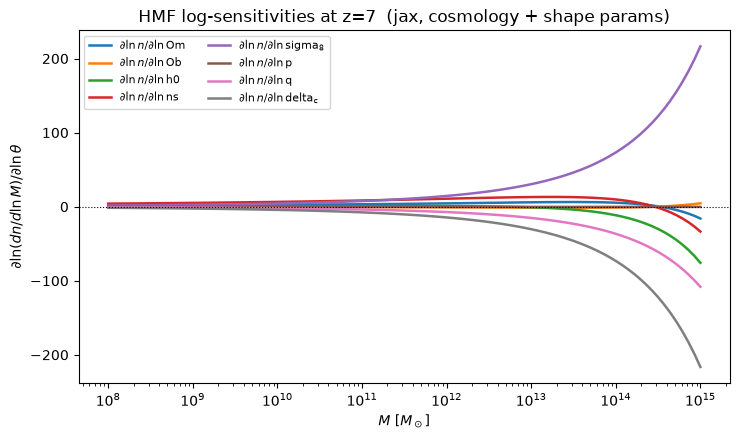

In [28]:
if _JAX:
    Jm = jax.jacobian(
        lambda v: jnp.log(dndlnm_diff(
            jnp.asarray(M), z,
            v[0], v[1], v[2], v[3], v[4],
            p=v[5], q=v[6], delta_c=v[7], A=A_st, backend='jax'))
    )(vec0_h)   # (n_M, 8)

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    for i, n in enumerate(names_h):
        ax.semilogx(M, np.asarray(Jm)[:, i] * theta_h[n], lw=1.8,
                    label=fr'$\partial \ln n / \partial \ln \mathrm{{{n}}}$')
    ax.axhline(0, color='k', lw=0.8, ls=':')
    ax.set_xlabel(r'$M\ [M_\odot]$')
    ax.set_ylabel(r'$\partial \ln (dn/d\ln M) / \partial \ln \theta$')
    ax.set_title(f'HMF log-sensitivities at z={z:.0f}  (jax, cosmology + shape params)')
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()
else:
    print('JAX is not installed — skipping this autodiff demo.')

<a id="sec5"></a>
## 5. Summary

| Concept | numpy default | Validated against | GPU | Autodiff (jax + torch) |
|---|---|---|---|---|
| P(k) — E&H no-wiggle | `EisensteinHu` | σ₈ integral, CAMB | ✔ `backend=` / `pk_eh_nowiggle` | ✔ all of (Ωm, Ωb, h₀, n_s, σ₈) |
| Growth D(z), f₁ | `beorn.cosmo.D` | CAMB ratio, Linder f₁ | device-resident | ✔ (a, Ωm); f₁ by exact autodiff |
| HMF dn/dlnM | `HaloMassFunction` | colossus | ✔ f(ν) kernel (~10× on Apple MPS) | ✔ shape (δ_c, p, q) via class; all 8 params via `dndlnm_diff` |

Design rules used throughout: numpy defaults unchanged; differentiable/GPU variants are opt-in via `backend=`; static geometry (k-nodes, quadrature grids) stays numpy-constant; nothing calls `.numpy()`/`float()` on values carrying gradients. MPS is float32-only; jax needs `jax_enable_x64` for float64.